In [138]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import scipy.io as sio
from scipy.linalg import orth
import numpy.random as npr

import sys
sys.path.insert(1, '/Users/albert/Paper-Replications/sca-REPLICATION/SCA')
from architecture import SCA_encoder, SCA_decoder
from model import SCA

## Generating Toy Data

In [139]:
def create_sine(T,C):
    tau=T/(2*np.pi)/C
    return torch.sin(torch.arange(0,T)/tau)

In [140]:
np.random.seed(0) #To get the same simulated data

T=1200 #Time
N_neurons=50 #Number of neurons
R_sim=7 #Number of dimensions in lowD representations

#Orthogonal matrix that projects low dimensional space to full neural space
V_tmp=orth(npr.randn(R_sim,N_neurons).T).T 

Z = np.zeros([T,R_sim])
for i in range(R_sim):
    Z[150*i:150*i+300,i]=create_sine(300,i+1)

#Create high-dimensional neural activity    
b=npr.randn(N_neurons) #Offset of neurons
X0=Z@V_tmp[:R_sim,:]+b #Project into high-dimensional space and add offset
X0=X0+.1*npr.randn(X0.shape[0],X0.shape[1]) #Add noise

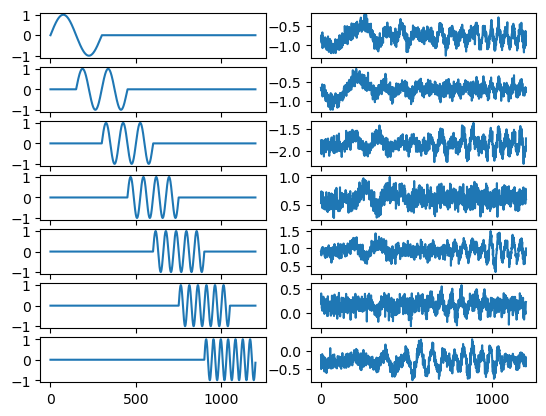

In [141]:
fig,ax = plt.subplots(R_sim,2)
for i in range(R_sim):
    ax[i,0].plot(Z[:,i])
    ax[i,1].plot(X0[:,i*3])

In [142]:
X0_torch = torch.from_numpy(X0.astype(np.float32))

data = SCA(X0_torch,R_sim,1000)

Epoch 1
-------------------------------
loss: 113608.132812  [    0/ 1000]
learning rate: 0.001000
Epoch 101
-------------------------------
loss: 74121.226562  [  100/ 1000]
Epoch 201
-------------------------------
loss: 44837.890625  [  200/ 1000]
Epoch 301
-------------------------------
loss: 27442.054688  [  300/ 1000]
Epoch 401
-------------------------------
loss: 14213.941406  [  400/ 1000]
Epoch 501
-------------------------------
loss: 10883.544922  [  500/ 1000]
Epoch 601
-------------------------------
loss: 11215.409180  [  600/ 1000]
Epoch 701
-------------------------------
loss: 11596.150391  [  700/ 1000]
Epoch 801
-------------------------------
loss: 11952.616211  [  800/ 1000]
Epoch 901
-------------------------------
loss: 12336.100586  [  900/ 1000]


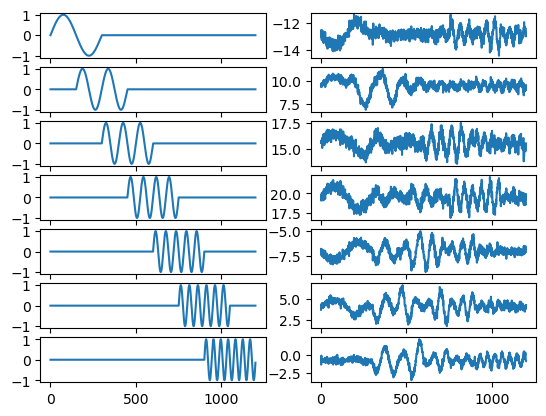

In [143]:
fig,ax = plt.subplots(R_sim,2)
for i in range(R_sim):
    ax[i,0].plot(Z[:,i])
    ax[i,1].plot(learned_latents.detach().numpy()[:,i])